# Exercício 2 - Modelagem de Tópicos

O objetivo desse exercício é utilizar uma das principais técnicas de NLP para mineração de dados em um conjunto de documentos. A modelagem de tópicos consiste em, dado um conjunto de documentos, extrair os principais temas - ou como o próprio nome diz, tópicos - presentes nos documentos.

In [14]:
import pandas as pd
import numpy as np
import re
import nltk
import unicodedata
import string
import spacy
from nltk.corpus import stopwords

A base TREC contem textos, que são perguntas curtas. Seus rótulos, que provavelmente nãos erão utilizados, classificam a pergunta em 6 categorias principais: humano, localização, entidade, abreviação, descrição e valor numérico.

In [3]:
texts_file = "data/texts.txt"
scores_file = "data/scores.txt"

with open(texts_file, "r", encoding="utf-8") as f:
    texts = [line.strip() for line in f.readlines()]

with open(scores_file, "r", encoding="utf-8") as f:
    labels = [line.strip() for line in f.readlines()]

if len(texts) != len(labels):
    raise ValueError(f"Quantidade de textos ({len(texts)}) e labels ({len(labels)}) não bate!")

In [10]:
df = pd.DataFrame({"text": texts, "label": labels})
display(df)

,text,label
0,How did serfdom develop in and then leave Russ...,0
1,What films featured the character Popeye Doyle ?,1
2,How can I find a list of celebrities ' real na...,0
3,What fowl grabs the spotlight after the Chines...,1
4,What is the full form of .com ?,2
...,...,...
5947,Who was the 22nd President of the US ?,3
5948,What is the money they use in Zambia ?,1
5949,How many feet in a mile ?,5
5950,What is the birthstone of October ?,1


## Passo 2: Pré-processamento

Analisando o tamanho e densidade dos textos antres do pré-processamento

In [11]:
def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\b\w+\b", text)
    return tokens

# Cálculo das métricas
df["tokens"] = df["text"].apply(tokenize)
df["num_tokens"] = df["tokens"].apply(len)
df["unique_tokens"] = df["tokens"].apply(lambda x: len(set(x)))

# densidade lexical = número de tokens únicos / tokens totais
df["lexical_density"] = df["unique_tokens"]/df["num_tokens"].replace(0, np.nan)

df.head()


,text,label,tokens,num_tokens,unique_tokens,lexical_density
0,How did serfdom develop in and then leave Russ...,0,"[how, did, serfdom, develop, in, and, then, le...",9,9,1.000000
1,What films featured the character Popeye Doyle ?,1,"[what, films, featured, the, character, popeye...",7,7,1.000000
2,How can I find a list of celebrities ' real na...,0,"[how, can, i, find, a, list, of, celebrities, ...",10,10,1.000000
3,What fowl grabs the spotlight after the Chines...,1,"[what, fowl, grabs, the, spotlight, after, the...",12,10,0.833333
4,What is the full form of .com ?,2,"[what, is, the, full, form, of, com]",7,7,1.000000


In [12]:
print("\nEstatísticas do conjunto de documentos:")
print(df[["num_tokens", "unique_tokens", "lexical_density"]].describe())



Estatísticas do conjunto de documentos:
        num_tokens  unique_tokens  lexical_density
count  5952.000000    5952.000000      5952.000000
mean      8.815860       8.506048         0.974294
std       3.671528       3.340272         0.052086
min       2.000000       2.000000         0.615385
25%       6.000000       6.000000         1.000000
50%       8.000000       8.000000         1.000000
75%      11.000000      10.000000         1.000000
max      33.000000      29.000000         1.000000


<Axes: >

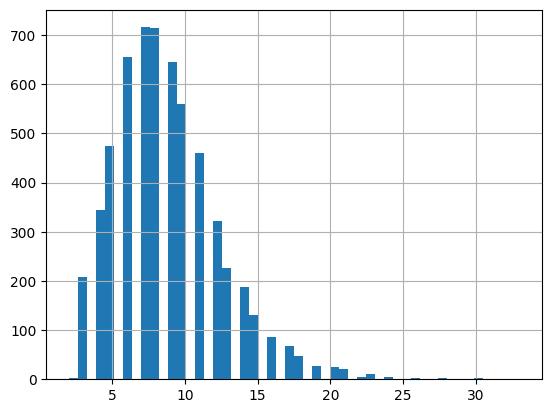

In [13]:
df["num_tokens"].hist(bins=50)

Pré-processamento

In [15]:
nltk.download('stopwords', quiet=True)

nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])
stopwords_en = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Aplica um pipeline completo de pré-processamento em uma string de texto.
    """

    # Passo 1 - Converter para minúsculas e remover acentuação
    text = text.lower()
    text = ''.join(
        caractere for caractere in unicodedata.normalize('NFD', text)
        if unicodedata.category(caractere) != 'Mn'
    )

    # Passo 2 - Remover menções e hashtags
    text = re.sub(r"[@#][\w@]+", " ", text)

    # Passo 3 - Reduzir repetições de caracteres (ex: "loooove" → "loove")
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Passo 4 - Remover URLs
    text = re.sub(r'(http[s]?://\S+|www\.\S+)', '', text, flags=re.IGNORECASE)

    # Passo 5 - Remover pontuação
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Passo 6 - Tokenizar e remover stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords_en]

    # Rejunta o texto para passar pelo SpaCy
    text = " ".join(tokens)

    # Passo 7 - Remover entidades (organizações, locais)
    doc = nlp(text)
    entidades_para_remover = {"ORG", "GPE", "LOC"}
    tokens_filtrados = [token.text for token in doc if token.ent_type_ not in entidades_para_remover]

    # Atualiza o texto
    text = " ".join(tokens_filtrados)

    # Passo 8 - Remover tokens numéricos
    tokens = text.split()
    tokens = [t for t in tokens if not re.search(r'\d', t)]

    # Passo 9 - Remover palavras curtas (< 3 letras)
    tokens = [t for t in tokens if len(t) >= 3]

    # Passo 10 - Remover nomes de pessoas
    doc = nlp(" ".join(tokens))
    tokens = [token.text for token in doc if token.ent_type_ != "PERSON"]

    # Passo 11 - Lematização final
    doc = nlp(" ".join(tokens))
    tokens_lematizados = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]

    return " ".join(tokens_lematizados)

df["clean_text"] = df["text"].apply(preprocess_text)

In [16]:
display(df)

,text,label,tokens,num_tokens,unique_tokens,lexical_density,clean_text
0,How did serfdom develop in and then leave Russ...,0,"[how, did, serfdom, develop, in, and, then, le...",9,9,1.000000,serfdom develop leave russia
1,What films featured the character Popeye Doyle ?,1,"[what, films, featured, the, character, popeye...",7,7,1.000000,film feature character popeye doyle
2,How can I find a list of celebrities ' real na...,0,"[how, can, i, find, a, list, of, celebrities, ...",10,10,1.000000,find list celebrity real name
3,What fowl grabs the spotlight after the Chines...,1,"[what, fowl, grabs, the, spotlight, after, the...",12,10,0.833333,fowl grabs spotlight chinese year monkey
4,What is the full form of .com ?,2,"[what, is, the, full, form, of, com]",7,7,1.000000,form com
...,...,...,...,...,...,...,...
5947,Who was the 22nd President of the US ?,3,"[who, was, the, 22nd, president, of, the, us]",8,7,0.875000,president
5948,What is the money they use in Zambia ?,1,"[what, is, the, money, they, use, in, zambia]",8,8,1.000000,money use zambia
5949,How many feet in a mile ?,5,"[how, many, feet, in, a, mile]",6,6,1.000000,foot mile
5950,What is the birthstone of October ?,1,"[what, is, the, birthstone, of, october]",6,6,1.000000,birthstone october


In [17]:
def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\b\w+\b", text)
    return tokens

# Cálculo das métricas
df["tokens_clean"] = df["clean_text"].apply(tokenize)
df["num_tokens_clean"] = df["tokens_clean"].apply(len)
df["unique_tokens_clean"] = df["tokens_clean"].apply(lambda x: len(set(x)))

# densidade lexical = número de tokens únicos / tokens totais
df["lexical_density_clean"] = df["unique_tokens_clean"]/df["num_tokens_clean"].replace(0, np.nan)

df.head()


,text,label,tokens,num_tokens,unique_tokens,lexical_density,clean_text,tokens_clean,num_tokens_clean,unique_tokens_clean,lexical_density_clean
0,How did serfdom develop in and then leave Russ...,0,"[how, did, serfdom, develop, in, and, then, le...",9,9,1.000000,serfdom develop leave russia,"[serfdom, develop, leave, russia]",4,4,1.0
1,What films featured the character Popeye Doyle ?,1,"[what, films, featured, the, character, popeye...",7,7,1.000000,film feature character popeye doyle,"[film, feature, character, popeye, doyle]",5,5,1.0
2,How can I find a list of celebrities ' real na...,0,"[how, can, i, find, a, list, of, celebrities, ...",10,10,1.000000,find list celebrity real name,"[find, list, celebrity, real, name]",5,5,1.0
3,What fowl grabs the spotlight after the Chines...,1,"[what, fowl, grabs, the, spotlight, after, the...",12,10,0.833333,fowl grabs spotlight chinese year monkey,"[fowl, grabs, spotlight, chinese, year, monkey]",6,6,1.0
4,What is the full form of .com ?,2,"[what, is, the, full, form, of, com]",7,7,1.000000,form com,"[form, com]",2,2,1.0


In [19]:
print("\nEstatísticas do conjunto de documentos após pré processamento:")
print(df[["num_tokens_clean", "unique_tokens_clean", "lexical_density_clean"]].describe())



Estatísticas do conjunto de documentos após pré processamento:
       num_tokens_clean  unique_tokens_clean  lexical_density_clean
count       5952.000000          5952.000000            5948.000000
mean           3.939684             3.909946               0.994590
std            1.947528             1.920524               0.035247
min            0.000000             0.000000               0.500000
25%            3.000000             3.000000               1.000000
50%            4.000000             4.000000               1.000000
75%            5.000000             5.000000               1.000000
max           15.000000            15.000000               1.000000


<Axes: >

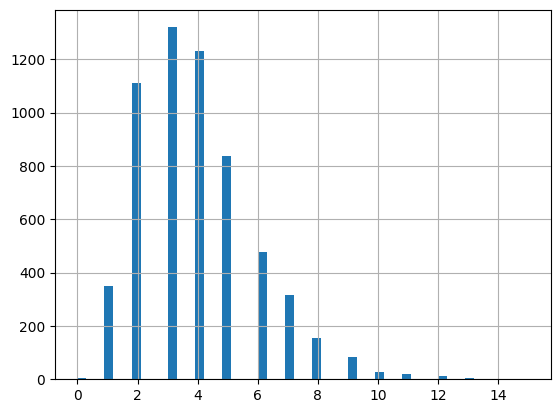

In [20]:
df["num_tokens_clean"].hist(bins=50)

In [22]:
df.to_csv("data/processed/trec_clean.csv", index=False)